# Notebook 2: Build Filtered Ontario Road Networks

## Objectives

This notebook loads the Ontario National Road Network (NRN) road segment layer and constructs reduced network representations for infrastructure and freight modelling.

Two nested road network representations are considered:

1. **Backbone network**
    - Freeway
    - Expressway / Highway
    - Ramp

2. **Freight-access network**
    - Freeway
    - Expressway / Highway
    - Ramp
    - Arterial

The purpose of these filters is to reduce graph size prior to graph construction while preserving the major transportation corridors required for national-scale energy and industrial systems modelling.

The resulting GeoDataFrames will serve as inputs to subsequent notebooks for:

- Canada-wide network assembly
- Graph construction
- Graph simplification
- Region-to-region connectivity
- TEMOA encoding

In [7]:
from pathlib import Path
import sqlite3

import pandas as pd
import geopandas as gpd

# Define the location of the raw National Road Network (NRN) data

raw_nrn = Path(
    r"C:\Users\aviga\Research\repos\temoa_geospace\data_files\raw\nrn"
)

# Province and territory abbreviations used throughout the preprocessing workflow

provinces = [
    "AB", "BC", "MB", "NB", "NL", "NS",
    "NT", "NU", "ON", "PE", "QC", "SK", "YT"
]

In [11]:
# Locate the English GeoPackage corresponding to a province or territory

def get_nrn_gpkg_path(province: str) -> Path:
    province = province.upper()
    province_dir = raw_nrn / province
    matches = list(province_dir.glob("*_en.gpkg"))

    if len(matches) != 1:
        raise ValueError(
            f"Expected exactly one English GPKG file for {province}, "
            f"found {len(matches)}."
        )

    return matches[0]

# Read the contents of a GeoPackage into a DataFrame
def get_gpkg_contents(gpkg_path: Path) -> pd.DataFrame:

    with sqlite3.connect(gpkg_path) as conn:

        contents = pd.read_sql_query(
            """
            SELECT *
            FROM gpkg_contents
            """,
            conn
        )

    return contents

# Determine the ROADSEG table name within a province's GeoPackage.
# Table names contain version numbers and therefore cannot be hardcoded. 

def get_roadseg_table(gpkg_path: Path) -> str:
    contents = get_gpkg_contents(gpkg_path)

    matches = contents[
        contents["table_name"].str.endswith("_ROADSEG")
    ]["table_name"].tolist()

    if len(matches) != 1:
        raise ValueError(
            f"Expected exactly one ROADSEG table in {gpkg_path.name}, "
            f"found {len(matches)}: {matches}"
        )

    return matches[0]

In [12]:
# Define nested road network representations.
#
# Backbone network:
# Long-distance freight corridors consisting of freeways, highways, and ramps.
#
# Freight-access network:
# Backbone network plus arterial roads to improve connectivity to industrial sites,
# ports, terminals, and regional centroids.

backbone_classes = [
    "Freeway",
    "Expressway / Highway",
    "Ramp",
]

freight_access_classes = backbone_classes + [
    "Arterial",
]

In [13]:
# Load Ontario road segments from the GeoPackage

province = "ON"

gpkg_path = get_nrn_gpkg_path(province)
roadseg_table = get_roadseg_table(gpkg_path)

roads_on = gpd.read_file(
    gpkg_path,
    layer=roadseg_table
)

roads_on["province"] = province

In [14]:
# Construct filtered road network representations for Ontario

on_backbone = roads_on[
    roads_on["ROADCLASS"].isin(backbone_classes)
].copy()

on_freight_access = roads_on[
    roads_on["ROADCLASS"].isin(freight_access_classes)
].copy()

In [15]:
# Compare the number of segments in each network representation

print(f"Full network: {roads_on.shape[0]:,}")
print(f"Backbone network: {on_backbone.shape[0]:,}")
print(f"Freight-access network: {on_freight_access.shape[0]:,}")

Full network: 651,662
Backbone network: 26,964
Freight-access network: 123,799


<Axes: >

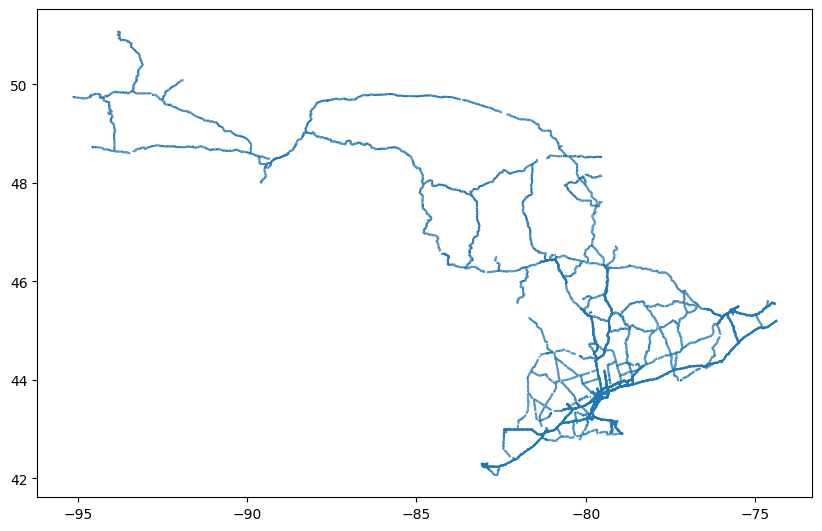

In [16]:
# Visualize Ontario's backbone freight network

on_backbone.plot(
    figsize=(10,10)
)

Ontario Backbone Network

The Ontario backbone network was constructed by filtering the National Road Network (NRN) to include:

Freeway
Expressway / Highway
Ramp

The resulting network contains 26,964 segments, representing approximately 4.1% of the complete Ontario NRN. Despite this reduction, the major transportation corridors of the province remain intact, suggesting that ROADCLASS filtering provides an effective first-stage graph reduction strategy for national-scale freight and infrastructure modelling.

<Axes: >

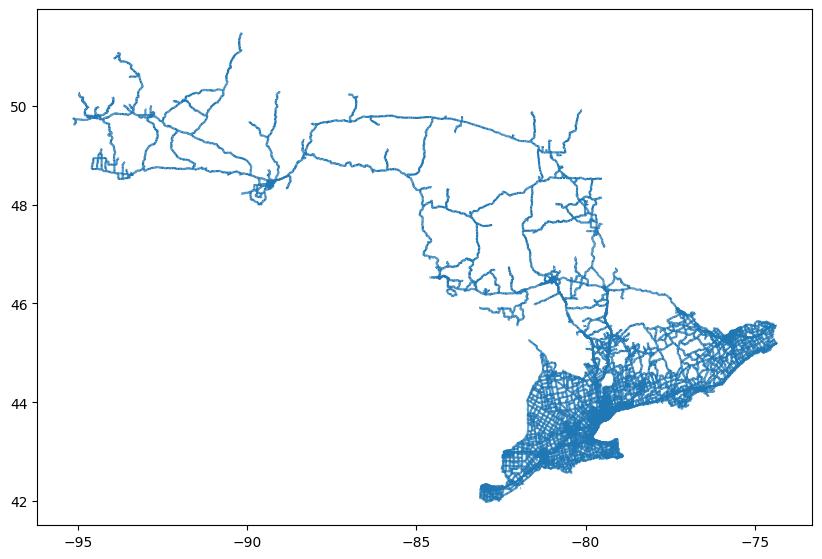

In [19]:
# Visualize Ontario's extended freight access network

on_freight_access.plot(
    figsize=(10,10)
)

# Conclusions

Ontario contains 651,662 road segments in the complete National Road Network.

Filtering by ROADCLASS provides substantial reductions in network size:

| Network | Segments | Fraction of Full Network |
|----------|---------:|-------------------------:|
| Full network | 651,662 | 100% |
| Backbone network | 26,964 | 4.1% |
| Freight-access network | 123,799 | 19.0% |

Despite these reductions, the major transportation corridors of Ontario remain intact, including:

- Highway 401 corridor
- Highway 400/69 corridor
- Highway 11
- Highway 17
- Major GTA expressways

These results suggest that ROADCLASS filtering provides an effective first-stage graph reduction strategy for large-scale freight and infrastructure modelling.

The next notebook will extend this workflow to all provinces and territories in order to construct Canada-wide backbone and freight-access road networks.